# CarRacing-v3 — Stable-Baselines3 PPO Baseline

This notebook contains the Stable-Baselines3 PPO baseline used for comparison with the custom Scratch PPO implementation. It includes preprocessing, checkpointed training/resume, deterministic 10-episode evaluation, gameplay recording, and final result plots.


## 1. Setup
Run this cell once in Colab. A GPU is recommended for training.


In [2]:
!pip -q install "gymnasium[box2d]" "stable-baselines3[extra]" opencv-python imageio imageio-ffmpeg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 17.1 MB/s eta 0:00:00


In [3]:
import os
import random
from collections import deque
from dataclasses import dataclass

import cv2
import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal
from torch.optim import Adam
from gymnasium import spaces

from stable_baselines3 import PPO as SB3PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Gymnasium:", gym.__version__)
print("PyTorch:", torch.__version__)

# Google Drive is mounted in the training section so checkpoints survive Colab resets.


Device: cpu
Gymnasium: 1.3.0
PyTorch: 2.11.0+cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# ============================================================
# GOOGLE DRIVE + PROJECT PATHS
# Run once after imports whenever Colab runtime restarts
# ============================================================

from google.colab import drive
import os

drive.mount("/content/drive")

# Main project folder
PROJECT_DIR = "/content/drive/MyDrive/CarRacing_PPO_Final"

# Scratch PPO
SCRATCH_SAVE_DIR = os.path.join(PROJECT_DIR, "checkpoints_scratch")

# Stable-Baselines3 PPO
SB3_CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints_sb3")
SB3_SAVE_PATH = os.path.join(PROJECT_DIR, "ppo_sb3_carracing")

# Videos / evaluation outputs
MEDIA_DIR = os.path.join(PROJECT_DIR, "media")

# Create folders
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(SCRATCH_SAVE_DIR, exist_ok=True)
os.makedirs(SB3_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Scratch checkpoints:", SCRATCH_SAVE_DIR)
print("SB3 checkpoints:", SB3_CHECKPOINT_DIR)
print("SB3 final model:", SB3_SAVE_PATH)
print("Media:", MEDIA_DIR)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/CarRacing_PPO_Final
Scratch checkpoints: /content/drive/MyDrive/CarRacing_PPO_Final/checkpoints_scratch
SB3 checkpoints: /content/drive/MyDrive/CarRacing_PPO_Final/checkpoints_sb3
SB3 final model: /content/drive/MyDrive/CarRacing_PPO_Final/ppo_sb3_carracing
Media: /content/drive/MyDrive/CarRacing_PPO_Final/media


## 2. Image preprocessing and frame stacking

We convert RGB frames to grayscale, resize to **84×84**, normalize to `[0, 1]`, and stack **4 consecutive frames**. The scratch implementation uses channel-first observations `(4, 84, 84)` for PyTorch.


In [5]:
FRAME_SIZE = 84
FRAME_STACK = 4


def preprocess_frame(frame, size=FRAME_SIZE):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (size, size), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0


class CarRacingFrameStack(gym.ObservationWrapper):
    """Preprocess CarRacing RGB observations and stack k frames, channel-first."""

    def __init__(self, env, k=FRAME_STACK, size=FRAME_SIZE):
        super().__init__(env)
        self.k = k
        self.size = size
        self.frames = deque(maxlen=k)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(k, size, size), dtype=np.float32
        )

    def observation(self, obs):
        frame = preprocess_frame(obs, self.size)
        self.frames.append(frame)
        while len(self.frames) < self.k:
            self.frames.append(frame.copy())
        return np.stack(self.frames, axis=0).astype(np.float32)

    def reset(self, **kwargs):
        self.frames.clear()
        obs, info = self.env.reset(**kwargs)
        return self.observation(obs), info


def make_scratch_env(render_mode="rgb_array", seed=SEED):
    env = gym.make("CarRacing-v3", render_mode=render_mode)
    env = CarRacingFrameStack(env, k=FRAME_STACK, size=FRAME_SIZE)
    env.action_space.seed(seed)
    return env


### Smoke test — run before any training
This verifies observation shape/range and the continuous action space.


In [6]:
env = make_scratch_env()
obs, info = env.reset(seed=SEED)
print("Observation:", obs.shape, obs.dtype, float(obs.min()), float(obs.max()))
print("Action space:", env.action_space)

assert obs.shape == (FRAME_STACK, FRAME_SIZE, FRAME_SIZE)
assert obs.dtype == np.float32
assert 0.0 <= obs.min() and obs.max() <= 1.0
assert env.action_space.shape == (3,)

random_action = env.action_space.sample()
next_obs, reward, terminated, truncated, info = env.step(random_action)
print("One step OK | reward:", reward, "| action:", random_action)
env.close()


Observation: (4, 84, 84) float32 0.0 0.7215686440467834
Action space: Box([-1.  0.  0.], 1.0, (3,), float32)
One step OK | reward: 6.967137809187279 | action: [0.5479121  0.43887845 0.85859793]


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


## 3. Stable-Baselines3 PPO Baseline

The baseline uses Stable-Baselines3 PPO with the same CarRacing-v3 task and image/frame-stack preprocessing. Checkpoints are stored in Google Drive so training can be resumed across Colab sessions.


In [ ]:
# ============================================================
# SB3 PPO — RESUME FROM 25K WITH REWARD MONITORING
# ============================================================

from stable_baselines3 import PPO as SB3PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.monitor import Monitor

import os
import cv2
import gymnasium as gym
import numpy as np
import imageio

from collections import deque
from gymnasium import spaces


# ------------------------------------------------------------
# Image preprocessing + 4-frame stacking
# ------------------------------------------------------------

class SB3CarRacingFrameStack(gym.ObservationWrapper):
    def __init__(self, env, k=FRAME_STACK, size=FRAME_SIZE):
        super().__init__(env)

        self.k = k
        self.size = size
        self.frames = deque(maxlen=k)

        self.observation_space = spaces.Box(
            low=0,
            high=255,
            shape=(size, size, k),
            dtype=np.uint8
        )

    def observation(self, obs):
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)

        frame = cv2.resize(
            gray,
            (self.size, self.size),
            interpolation=cv2.INTER_AREA
        ).astype(np.uint8)

        self.frames.append(frame)

        while len(self.frames) < self.k:
            self.frames.append(frame.copy())

        return np.stack(self.frames, axis=-1)

    def reset(self, **kwargs):
        self.frames.clear()
        obs, info = self.env.reset(**kwargs)
        return self.observation(obs), info


# ------------------------------------------------------------
# Environment WITH Monitor
# ------------------------------------------------------------

def make_sb3_env():
    env = gym.make("CarRacing-v3", render_mode="rgb_array")
    env = SB3CarRacingFrameStack(env)

    # This makes ep_rew_mean and ep_len_mean appear
    env = Monitor(env)

    return env


# ------------------------------------------------------------
# Drive paths
# ------------------------------------------------------------

SB3_CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints_sb3")
SB3_SAVE_PATH = os.path.join(PROJECT_DIR, "ppo_sb3_carracing")

SB3_25K_CHECKPOINT = os.path.join(
    SB3_CHECKPOINT_DIR,
    "ppo_sb3_carracing_25000_steps.zip"
)

os.makedirs(SB3_CHECKPOINT_DIR, exist_ok=True)

print("Loading checkpoint:", SB3_25K_CHECKPOINT)


# ------------------------------------------------------------
# Create monitored environment
# ------------------------------------------------------------

vec_env = DummyVecEnv([make_sb3_env])
vec_env = VecTransposeImage(vec_env)


# ------------------------------------------------------------
# Load the already-trained 25k PPO model
# ------------------------------------------------------------

sb3_model = SB3PPO.load(
    SB3_25K_CHECKPOINT,
    env=vec_env,
    device="auto"
)

print("Checkpoint loaded successfully")
print("Device:", sb3_model.device)


# ------------------------------------------------------------
# Continue checkpointing
# ------------------------------------------------------------

checkpoint_callback = CheckpointCallback(
    save_freq=25_000,
    save_path=SB3_CHECKPOINT_DIR,
    name_prefix="ppo_sb3_resumed",
    save_replay_buffer=False,
    save_vecnormalize=False
)


# ------------------------------------------------------------
# Continue 275k more steps
#
# 25k existing + 275k = 300k total
# ------------------------------------------------------------

REMAINING_TIMESTEPS = 275_000

print("\nResuming SB3 PPO...")
print("Already trained: 25,000")
print("Remaining:", REMAINING_TIMESTEPS)
print("Target total: ~300,000")


sb3_model.learn(
    total_timesteps=REMAINING_TIMESTEPS,
    callback=checkpoint_callback,
    reset_num_timesteps=False,
    progress_bar=False
)


# ------------------------------------------------------------
# Save final 300k model
# ------------------------------------------------------------

sb3_model.save(SB3_SAVE_PATH)

print("\n========================================")
print("SB3 TRAINING COMPLETE")
print("========================================")
print("Final model:", SB3_SAVE_PATH)
print("Checkpoints:", SB3_CHECKPOINT_DIR)


vec_env.close()

Loading checkpoint: /content/drive/MyDrive/CarRacing_PPO_Final/checkpoints_sb3/ppo_sb3_carracing_25000_steps.zip
Checkpoint loaded successfully
Device: cuda

Resuming SB3 PPO...
Already trained: 25,000
Remaining: 275000
Target total: ~300,000
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -17.7    |
| time/              |          |
|    fps             | 83       |
|    iterations      | 1        |
|    time_elapsed    | 24       |
|    total_timesteps | 27048    |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -35.4        |
| time/                   |              |
|    fps                  | 84           |
|    iterations           | 2            |
|    time_elapsed         | 48           |
|    total_timesteps      | 29096        |
| train/                  |   

In [ ]:
# ============================================================
# SB3 ENVIRONMENT DEFINITIONS
# Run after every Colab runtime restart
# ============================================================

import gymnasium as gym
import cv2
import numpy as np

from collections import deque
from gymnasium import spaces
from stable_baselines3.common.monitor import Monitor


class SB3CarRacingFrameStack(gym.ObservationWrapper):
    def __init__(self, env, k=FRAME_STACK, size=FRAME_SIZE):
        super().__init__(env)

        self.k = k
        self.size = size
        self.frames = deque(maxlen=k)

        self.observation_space = spaces.Box(
            low=0,
            high=255,
            shape=(size, size, k),
            dtype=np.uint8
        )

    def observation(self, obs):
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)

        frame = cv2.resize(
            gray,
            (self.size, self.size),
            interpolation=cv2.INTER_AREA
        ).astype(np.uint8)

        self.frames.append(frame)

        while len(self.frames) < self.k:
            self.frames.append(frame.copy())

        return np.stack(self.frames, axis=-1)

    def reset(self, **kwargs):
        self.frames.clear()

        obs, info = self.env.reset(**kwargs)

        return self.observation(obs), info


def make_sb3_env():
    env = gym.make("CarRacing-v3", render_mode="rgb_array")
    env = SB3CarRacingFrameStack(env)
    env = Monitor(env)

    return env


print("SB3 environment definitions loaded.")

SB3 environment definitions loaded.


In [ ]:
# ============================================================
# SB3 PPO — RESUME ~250K -> ~300K
# ============================================================

from stable_baselines3 import PPO as SB3PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.monitor import Monitor

# Latest checkpoint
SB3_250K_CHECKPOINT = os.path.join(
    PROJECT_DIR,
    "checkpoints_sb3",
    "ppo_sb3_resumed_225000_steps.zip"
)

print("Loading:", SB3_250K_CHECKPOINT)

# Environment with reward monitoring
def make_sb3_env():
    env = gym.make("CarRacing-v3", render_mode="rgb_array")
    env = SB3CarRacingFrameStack(env)
    env = Monitor(env)
    return env

vec_env = DummyVecEnv([make_sb3_env])
vec_env = VecTransposeImage(vec_env)

# Load trained model
sb3_model = SB3PPO.load(
    SB3_250K_CHECKPOINT,
    env=vec_env,
    device="auto"
)

print("Checkpoint loaded")
print("Device:", sb3_model.device)

# Continue saving to Drive
SB3_CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints_sb3")
SB3_SAVE_PATH = os.path.join(PROJECT_DIR, "ppo_sb3_carracing")

checkpoint_callback = CheckpointCallback(
    save_freq=25_000,
    save_path=SB3_CHECKPOINT_DIR,
    name_prefix="ppo_sb3_final",
    save_replay_buffer=False,
    save_vecnormalize=False
)

# Approximately 250k already trained + 50k = 300k
sb3_model.learn(
    total_timesteps=50_000,
    callback=checkpoint_callback,
    reset_num_timesteps=False,
    progress_bar=False
)

# Save final model
sb3_model.save(SB3_SAVE_PATH)
vec_env.close()

print("\nSB3 ~300K TRAINING COMPLETE")
print("Final model saved:", SB3_SAVE_PATH)

Loading: /content/drive/MyDrive/CarRacing_PPO_Final/checkpoints_sb3/ppo_sb3_resumed_225000_steps.zip
Checkpoint loaded
Device: cuda


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 995      |
|    ep_rew_mean     | 254      |
| time/              |          |
|    fps             | 80       |
|    iterations      | 1        |
|    time_elapsed    | 25       |
|    total_timesteps | 227048   |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 995         |
|    ep_rew_mean          | 255         |
| time/                   |             |
|    fps                  | 80          |
|    iterations           | 2           |
|    time_elapsed         | 51          |
|    total_timesteps      | 229096      |
| train/                  |             |
|    approx_kl            | 0.027310045 |
|    clip_fraction        | 0.322       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.12       |
|    explained_variance   | 0.913       |
|    learning_rate        | 0.

## 4. Final Evaluation and Gameplay

The final SB3 policy is evaluated deterministically on 10 fixed tracks. The same evaluation protocol is used when comparing against Scratch PPO.


In [ ]:
# ============================================================
# SB3 FINAL EVALUATION + DEMO VIDEO
# ============================================================

from stable_baselines3 import PPO as SB3PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage
from IPython.display import Video, display
import numpy as np
import imageio
import os

SB3_SAVE_PATH = os.path.join(PROJECT_DIR, "ppo_sb3_carracing")
sb3_video_path = os.path.join(MEDIA_DIR, "sb3_ppo_demo.mp4")

# Create env and load model
vec_env = DummyVecEnv([make_sb3_env])
vec_env = VecTransposeImage(vec_env)

sb3_model = SB3PPO.load(
    SB3_SAVE_PATH,
    env=vec_env,
    device="auto"
)

print("Final SB3 model loaded.")


def evaluate_sb3(model, episodes=10, record_path=None, seed=100):
    rewards = []
    frames = []

    for ep in range(episodes):
        env = make_sb3_env()
        obs, _ = env.reset(seed=seed + ep)

        done = False
        episode_reward = 0.0

        while not done:
            obs_chw = np.transpose(obs, (2, 0, 1))[None, ...]

            action, _ = model.predict(
                obs_chw,
                deterministic=True
            )

            obs, reward, terminated, truncated, _ = env.step(action[0])

            done = terminated or truncated
            episode_reward += reward

            if record_path is not None and ep == 0:
                frames.append(env.render())

        rewards.append(episode_reward)
        env.close()

        print(f"SB3 eval episode {ep + 1}: {episode_reward:.1f}")

    if record_path is not None:
        imageio.mimsave(
            record_path,
            frames,
            fps=30,
            macro_block_size=16
        )
        print("Video saved:", record_path)

    print(
        f"SB3 mean reward over {episodes} episodes: "
        f"{np.mean(rewards):.1f} +/- {np.std(rewards):.1f}"
    )

    print(f"Best episode: {np.max(rewards):.1f}")
    print(f"Worst episode: {np.min(rewards):.1f}")

    return rewards


# Run 10-episode evaluation
sb3_eval_rewards = evaluate_sb3(
    sb3_model,
    episodes=10,
    record_path=sb3_video_path,
    seed=100
)

# Display video
display(
    Video(
        sb3_video_path,
        embed=True,
        width=700
    )
)

vec_env.close()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# WATCH BEST SB3 EVALUATION EPISODE
# Episode 7 = seed 106 = reward ~547.5
# ============================================================

from IPython.display import Video, display
import numpy as np
import imageio
import os

BEST_SEED = 106

best_video_path = os.path.join(
    MEDIA_DIR,
    "sb3_best_episode_seed106.mp4"
)

env = make_sb3_env()
obs, _ = env.reset(seed=BEST_SEED)

done = False
episode_reward = 0.0
frames = []

while not done:
    obs_chw = np.transpose(obs, (2, 0, 1))[None, ...]

    action, _ = sb3_model.predict(
        obs_chw,
        deterministic=True
    )

    obs, reward, terminated, truncated, _ = env.step(action[0])

    done = terminated or truncated
    episode_reward += reward
    frames.append(env.render())

env.close()

imageio.mimsave(
    best_video_path,
    frames,
    fps=30,
    macro_block_size=16
)

print(f"Episode reward: {episode_reward:.1f}")
print("Video saved:", best_video_path)

display(
    Video(
        best_video_path,
        embed=True,
        width=700
    )
)

Output hidden; open in https://colab.research.google.com to view.

FINAL SB3 PPO RESULTS
Training steps      : ~300,000
Evaluation episodes : 10
Mean reward         : 220.5
Standard deviation  : 173.5
Best episode        : 547.5
Worst episode       : 44.4


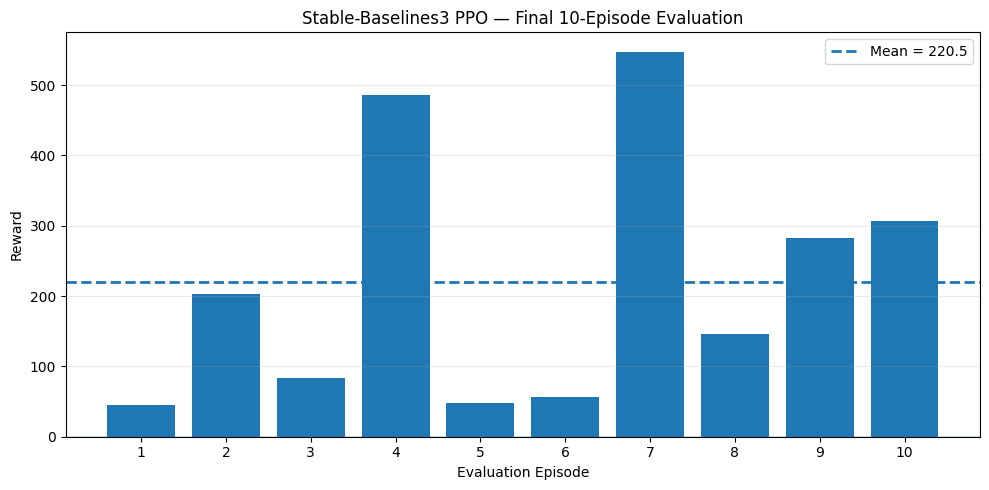

Saved: /content/drive/MyDrive/CarRacing_PPO_Final/results/sb3_final_evaluation.png


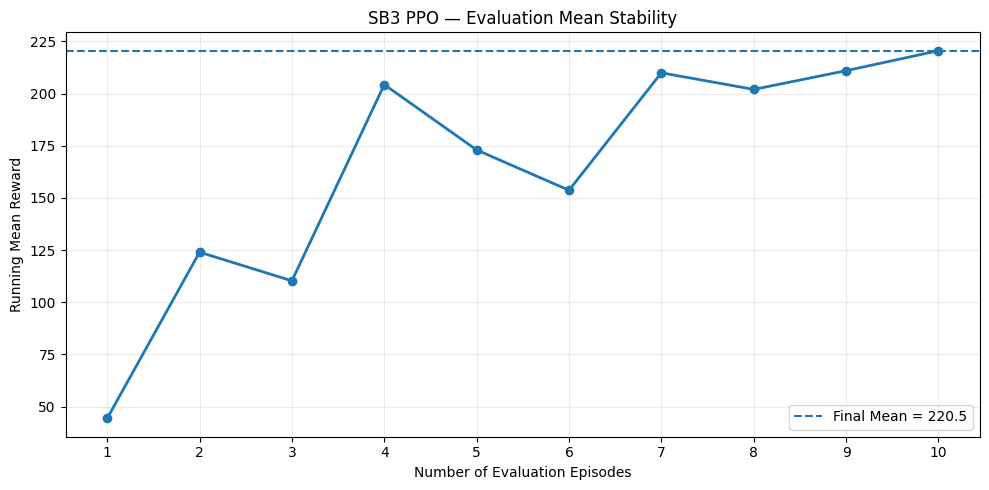

Saved: /content/drive/MyDrive/CarRacing_PPO_Final/results/sb3_evaluation_running_mean.png

FINAL SB3 PPO SUMMARY
---------------------------------------------
Mean  : 220.5
Std   : 173.5
Best  : 547.5
Worst : 44.4

Plots saved in:
/content/drive/MyDrive/CarRacing_PPO_Final/results


In [7]:
# ============================================================
# FINAL SB3 PPO — RESULTS & PLOTS
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

SB3_RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

os.makedirs(SB3_RESULTS_DIR, exist_ok=True)


# ============================================================
# 1. FINAL 10-EPISODE RESULTS
# ============================================================

sb3_eval_scores = np.array([
    44.4,
    203.6,
    82.8,
    486.3,
    47.7,
    57.1,
    547.5,
    146.3,
    282.7,
    306.6
])

sb3_mean = sb3_eval_scores.mean()
sb3_std = sb3_eval_scores.std()
sb3_best = sb3_eval_scores.max()
sb3_worst = sb3_eval_scores.min()

print("=" * 60)
print("FINAL SB3 PPO RESULTS")
print("=" * 60)

print("Training steps      : ~300,000")
print(f"Evaluation episodes : {len(sb3_eval_scores)}")
print(f"Mean reward         : {sb3_mean:.1f}")
print(f"Standard deviation  : {sb3_std:.1f}")
print(f"Best episode        : {sb3_best:.1f}")
print(f"Worst episode       : {sb3_worst:.1f}")

print("=" * 60)


# ============================================================
# 2. FINAL 10-EPISODE EVALUATION PLOT
# ============================================================

episodes = np.arange(
    1,
    len(sb3_eval_scores) + 1
)

plt.figure(figsize=(10, 5))

plt.bar(
    episodes,
    sb3_eval_scores
)

plt.axhline(
    sb3_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {sb3_mean:.1f}"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xticks(episodes)

plt.xlabel("Evaluation Episode")
plt.ylabel("Reward")

plt.title(
    "Stable-Baselines3 PPO — Final 10-Episode Evaluation"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

evaluation_plot_path = os.path.join(
    SB3_RESULTS_DIR,
    "sb3_final_evaluation.png"
)

plt.savefig(
    evaluation_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", evaluation_plot_path)


# ============================================================
# 3. RUNNING EVALUATION MEAN
# ============================================================

running_mean = np.array([
    sb3_eval_scores[:i].mean()
    for i in range(
        1,
        len(sb3_eval_scores) + 1
    )
])

plt.figure(figsize=(10, 5))

plt.plot(
    episodes,
    running_mean,
    marker="o",
    linewidth=2
)

plt.axhline(
    sb3_mean,
    linestyle="--",
    label=f"Final Mean = {sb3_mean:.1f}"
)

plt.xticks(episodes)

plt.xlabel("Number of Evaluation Episodes")
plt.ylabel("Running Mean Reward")

plt.title(
    "SB3 PPO — Evaluation Mean Stability"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

running_plot_path = os.path.join(
    SB3_RESULTS_DIR,
    "sb3_evaluation_running_mean.png"
)

plt.savefig(
    running_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", running_plot_path)


# ============================================================
# 4. SUMMARY
# ============================================================

print("\nFINAL SB3 PPO SUMMARY")
print("-" * 45)

print(f"Mean  : {sb3_mean:.1f}")
print(f"Std   : {sb3_std:.1f}")
print(f"Best  : {sb3_best:.1f}")
print(f"Worst : {sb3_worst:.1f}")

print("\nPlots saved in:")
print(SB3_RESULTS_DIR)

## 5. Final Observations

The Stable-Baselines3 PPO baseline achieved **220.5 ± 173.6** mean reward across 10 fixed evaluation tracks, with a best episode of **547.5** and a worst episode of **44.4**. All 10 evaluation episodes were positive.

SB3 achieved a higher evaluation mean and better worst-case performance than the selected Scratch PPO checkpoint, providing a strong mature-library baseline for the custom implementation.
